BANK LOAN DATASET

Dataset:
    Gender Married     Education  ApplicantIncome  LoanAmount  CreditHistory  \
0     Male     Yes      Graduate             5000         150              1   
1   Female      No      Graduate             3000         100              1   
2     Male     Yes  Not Graduate             2500          80              0   
3     Male     Yes      Graduate             6000         200              1   
4   Female      No      Graduate             4000         120              1   
5     Male     Yes  Not Graduate             3500         100              0   
6   Female     Yes      Graduate             7000         250              1   
7     Male      No      Graduate             4500         150              1   
8   Female      No  Not Graduate             2800          90              0   
9     Male     Yes      Graduate             8000         300              1   
10    Male     Yes      Graduate             5500         180              1   
11  Female  

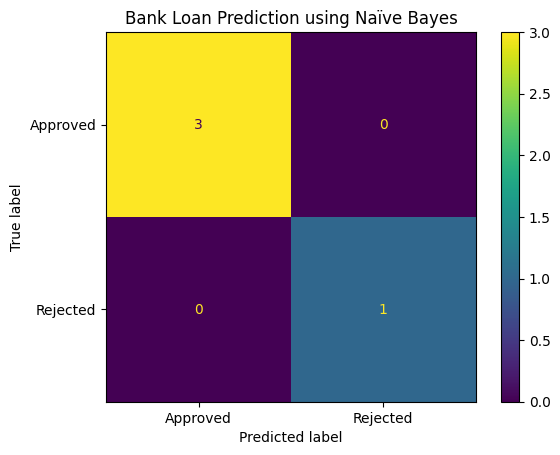


NEW LOAN APPLICATION PREDICTION

Applicant Details:
Gender          : Male
Married         : Yes
Education       : Graduate
Applicant Income: ₹6000
Loan Amount     : ₹180,000
Credit History  : Good

Predicted Loan Status:
LOAN APPROVED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
# Experiment: Bank Loan Prediction using Naïve Bayes
# Aim: Implement Naïve Bayes classification for
#      Bank Loan Prediction.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Create Bank Loan Dataset
# ---------------------------------------------------------

data = {
    "Gender": [
        "Male", "Female", "Male", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],

    "Married": [
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "No", "Yes",
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "Education": [
        "Graduate", "Graduate", "Not Graduate", "Graduate", "Graduate",
        "Not Graduate", "Graduate", "Graduate", "Not Graduate", "Graduate",
        "Graduate", "Graduate", "Not Graduate", "Graduate", "Graduate",
        "Not Graduate", "Graduate", "Graduate", "Not Graduate", "Graduate"
    ],

    "ApplicantIncome": [
        5000, 3000, 2500, 6000, 4000,
        3500, 7000, 4500, 2800, 8000,
        5500, 3200, 2700, 6500, 9000,
        3000, 7500, 5000, 2200, 6000
    ],

    "LoanAmount": [
        150, 100, 80, 200, 120,
        100, 250, 150, 90, 300,
        180, 110, 85, 200, 350,
        100, 280, 170, 70, 220
    ],

    "CreditHistory": [
        1, 1, 0, 1, 1,
        0, 1, 1, 0, 1,
        1, 0, 1, 1, 1,
        0, 1, 1, 0, 1
    ],

    "Loan_Status": [
        "Approved", "Approved", "Rejected", "Approved", "Approved",
        "Rejected", "Approved", "Approved", "Rejected", "Approved",
        "Approved", "Rejected", "Approved", "Approved", "Approved",
        "Rejected", "Approved", "Approved", "Rejected", "Approved"
    ]
}


df = pd.DataFrame(data)


print("BANK LOAN DATASET")
print("=" * 60)

print("\nDataset:")
print(df)

print("\nTotal number of samples:",
      len(df))


# ---------------------------------------------------------
# STEP 2: Encode Categorical Features
# ---------------------------------------------------------

label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(
    df["Gender"]
)

df["Married"] = label_encoder.fit_transform(
    df["Married"]
)

df["Education"] = label_encoder.fit_transform(
    df["Education"]
)

df["Loan_Status"] = label_encoder.fit_transform(
    df["Loan_Status"]
)


print("\nEncoded Dataset:")
print(df)


# ---------------------------------------------------------
# STEP 3: Separate Features and Target
# ---------------------------------------------------------

X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget: Loan Status")


# ---------------------------------------------------------
# STEP 4: Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining samples:",
      len(X_train))

print("Testing samples:",
      len(X_test))


# ---------------------------------------------------------
# STEP 5: Create Naïve Bayes Classifier
# ---------------------------------------------------------

model = GaussianNB()


# ---------------------------------------------------------
# STEP 6: Train the Model
# ---------------------------------------------------------

model.fit(
    X_train,
    y_train
)


print("\nNaïve Bayes model trained successfully!")


# ---------------------------------------------------------
# STEP 7: Predict Test Data
# ---------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ---------------------------------------------------------
# STEP 8: Calculate Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("NAÏVE BAYES BANK LOAN PREDICTION RESULTS")
print("=" * 60)

print("\nAccuracy:",
      round(accuracy * 100, 2),
      "%")


# ---------------------------------------------------------
# STEP 9: Display Actual vs Predicted Results
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(
    y_test,
    y_pred
):

    actual_status = (
        "Approved"
        if actual == 0
        else "Rejected"
    )

    predicted_status = (
        "Approved"
        if predicted == 0
        else "Rejected"
    )

    print(
        "Actual:",
        actual_status,
        "\tPredicted:",
        predicted_status
    )


# ---------------------------------------------------------
# STEP 10: Classification Report
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Approved",
            "Rejected"
        ]
    )
)


# ---------------------------------------------------------
# STEP 11: Generate Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 12: Display Confusion Matrix Graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Approved",
        "Rejected"
    ]
)

disp.plot()

plt.title(
    "Bank Loan Prediction using Naïve Bayes"
)

plt.show()


# ---------------------------------------------------------
# STEP 13: Predict a New Loan Application
# ---------------------------------------------------------

# Gender:
# Male = 1, Female = 0
#
# Married:
# Yes = 1, No = 0
#
# Education:
# Graduate = 0, Not Graduate = 1
#
# CreditHistory:
# 1 = Good, 0 = Poor


new_applicant = np.array([
    [1, 1, 0, 6000, 180, 1]
])


prediction = model.predict(
    new_applicant
)


print("\n" + "=" * 60)
print("NEW LOAN APPLICATION PREDICTION")
print("=" * 60)

print("\nApplicant Details:")

print("Gender          : Male")
print("Married         : Yes")
print("Education       : Graduate")
print("Applicant Income: ₹6000")
print("Loan Amount     : ₹180,000")
print("Credit History  : Good")


print("\nPredicted Loan Status:")

if prediction[0] == 0:

    print("LOAN APPROVED")

else:

    print("LOAN REJECTED")